# **Mestrado em Informática**
## *Aprendizagem Máquina*

# **Pós-Graduação em Data Science and Digital Transformation**

## *Análise de Dados e Aprendizagem Automática*

Mónica Vieira Martins 
---------------------

># Tutorial 03 - kNN e validação cruzada


`Diz-me quem são os teus vizinhos, dir-te-ei quem és`





Neste tutorial explora-se o treino, teste e optimização  de modelos de k vizinhos mais próximos, exemplificando-se a padronização de dados, e introduz-se o conceito de  validação cruzada para optimização de parâmetros.

# Dados


Neste tutorial vão ser utilizados os dados do dataset `titanic` que foram previamente pré-processados no tutorial anterior

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")


In [3]:
train= pd.read_csv("datasets/titanic_train.csv", sep=',')
test = pd.read_csv("datasets/titanic_test.csv", sep=',')

In [4]:
train.head()

,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0,Survived
0,3.0,29.745184,15.2458,2.0,0.0,0.0,0.0,0
1,2.0,31.000000,10.5000,0.0,1.0,0.0,1.0,0
2,2.0,31.000000,37.0042,2.0,1.0,0.0,0.0,0
3,3.0,20.000000,4.0125,0.0,1.0,0.0,0.0,0
4,3.0,21.000000,7.2500,0.0,1.0,0.0,1.0,0


In [5]:
test.head()

,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0,Survived
0,3.0,29.745184,14.4583,0.0,1.0,0.0,0.0,0
1,3.0,29.745184,7.5500,0.0,1.0,0.0,1.0,0
2,3.0,7.000000,29.1250,5.0,1.0,1.0,0.0,0
3,1.0,29.745184,146.5208,1.0,0.0,0.0,0.0,1
4,3.0,29.000000,15.2458,2.0,0.0,0.0,0.0,1


In [6]:
print(train.shape)
print(test.shape)

(712, 8)
(179, 8)


In [7]:
ytrain=train.Survived
ytest=test.Survived
ytrain.head()

0    0
1    0
2    0
3    0
4    0
Name: Survived, dtype: int64

In [8]:
Xtrain=train.drop("Survived", axis=1)
Xtest=test.drop("Survived", axis=1)
Xtrain.head()

,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0
0,3.0,29.745184,15.2458,2.0,0.0,0.0,0.0
1,2.0,31.000000,10.5000,0.0,1.0,0.0,1.0
2,2.0,31.000000,37.0042,2.0,1.0,0.0,0.0
3,3.0,20.000000,4.0125,0.0,1.0,0.0,0.0
4,3.0,21.000000,7.2500,0.0,1.0,0.0,1.0


In [7]:
Xtrain.describe()

,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0
count,712.000000,712.000000,712.00000,712.000000,712.000000,712.000000,712.000000
mean,2.317416,29.745184,31.86295,0.921348,0.653090,0.089888,0.728933
std,0.833767,13.089458,50.13531,1.664385,0.476321,0.286222,0.444823
min,1.000000,0.670000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,7.91770,0.000000,0.000000,0.000000,0.000000
50%,3.000000,29.745184,14.45625,0.000000,1.000000,0.000000,1.000000
75%,3.000000,35.000000,31.27500,1.000000,1.000000,0.000000,1.000000
max,3.000000,80.000000,512.32920,10.000000,1.000000,1.000000,1.000000


# kNN
A classe de `scikit-learn` que implementa o algoritmo dos k vizinhos mais próximos (kNN) é `KNeighborsClassifier`. 

Os principais parâmetros que afetam a performance do modelo são 
* o número de vizinhos mais próximos (k)
* a distância usada para calcular quais são os k vizinhos mais próximos.

Relativamente à distância, importa perceber que tipo de distância é adequada aos dados com que se vai trabalhar.
* A distância L1, ou "Distância de Manhattan" é mais adequada quando se trabalha com variáveis do tipo inteiro.
* A distância L2, ou Euclidiana (o método usado para calcular a distância entre dois pontos num referencial cartesiano), é mais adequada quando as variáveis possuem valores reais.

Esta última é a distância usada por defeito em `scikit learn` (`metric=minkowski, p=2`) como argumento do construtor de `KNeighborsClassifier`;

A documentação para KNeighborsClassifier pode ser consultada aqui:  
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html



## Funções para análisar os resultados


In [9]:
#Data frame para registo de performance 
performance = pd.DataFrame(columns=['Train Accuracy','Test Accuracy', "Test f1"])

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score, accuracy_score
rotulos=["Não sobreviveu", "Sobreviveu"]

def model_evaluation(acc_train, verdadeiros, previstos,  titulo):
  ''' Função que cria e imprime a 
    matriz de confusão de um dados modelo e respetivo relatório de classificação 
    preenche o df calssification report
    verdadeitos - rotulos evrdadeiros do conjunto de teste
    previstos - rotulos previstos pelo modelo no conjunto de teste
    acc_train - exatidão do modelo no conjunto de treino, calculada previamente
    titulo - nome do modelo
  '''
  conf_matrix =  confusion_matrix(verdadeiros, previstos,  normalize="true")
  s = sns.heatmap(conf_matrix, annot=True, cmap="Greens", 
              xticklabels=rotulos, yticklabels=rotulos)
  s.set(xlabel = "Rótulo Previsto", ylabel="Rótulo Verdadeiro", title=titulo)
  plt.show()
  print(classification_report(verdadeiros, previstos))
  #preencher DF com resumo da performance
  #Avaliar o modelo com a exatidão

 
  acc_test= accuracy_score(verdadeiros, previstos)
  f1 = f1_score(verdadeiros, previstos, average="macro" )
  
  performance.loc[titulo,
                  ['Train Accuracy','Test Accuracy', "Test f1"]] =[ 
                  '{0:.2f}'.format(acc_train),
                  '{0:.2f}'.format(acc_test), 
                 '{0:.2f}'.format(f1)]  
  display(performance)


## Modelo de Base


Comecemos por treinar e avaliar um modelo kNN de base, que posteriormente tentaremos melhorar.

In [11]:
from sklearn.neighbors import KNeighborsClassifier
#default : k=5
knn=KNeighborsClassifier()
#treinar o modelo
knn.fit(Xtrain, ytrain)
#gerar as predições para Xtest
ypred_test=knn.predict(Xtest)

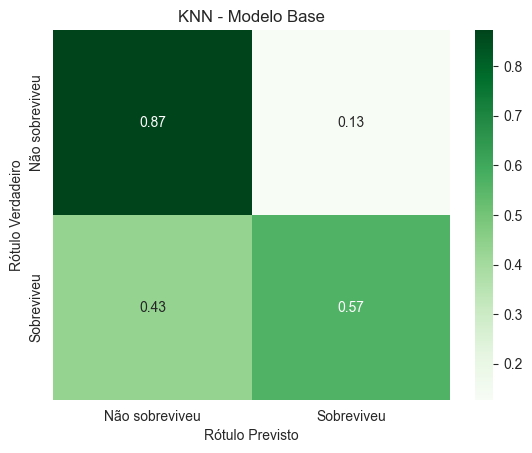

              precision    recall  f1-score   support

           0       0.76      0.87      0.81       110
           1       0.74      0.57      0.64        69

    accuracy                           0.75       179
   macro avg       0.75      0.72      0.73       179
weighted avg       0.75      0.75      0.75       179



,Train Accuracy,Test Accuracy,Test f1
KNN - Modelo Base,0.81,0.75,0.73


In [12]:
acc_train= knn.score(Xtrain, ytrain)
model_evaluation(acc_train, ytest, ypred_test, "KNN - Modelo Base" )

Verifica-se que o número de falsos "Não Sobreviveu" é muito elevado (43%).



Vejamos em seguida como se pode melhorar o modelo.

# Padronização / Normalização dos dados

Nos algoritmos em que é necessário calcular distâncias entres os vários exemplares dos dados, como no kNN, a diferente  escala de valores dos diferente atributos pode influenciar negativamente a performance do modelo.  Isto ocorre porque  a distância medida pode ser dominada pelo(s) atributos com valores mais elevados, reduzindo artificialmente a importância dos outros atributos.

Outros algoritmos que são sensíveis à escala dos dados são as Máquinas de Suporte Vetorial e as Redes Neuronais.

Nestes casos, a **padronização** ou a  **normalização** dos dados deve fazer parte do pré-processamento.



Como já vimos, os métodos mais comuns e  disponíveis  em `sklearn` para  obter dados padronizados/normalizados são:
* `StandardScaler` : transforma cada um dos vetores de atributos por forma a que a sua média seja 0 e o desvio padrão seja 1. Não garante qualquer valor mínimo ou máximo dos valores transformados.
* `RobustScaler`: funciona de forma semelhante ao `StandardScaler`, mas ignora *outliers*, isto é, valores que se desviam muito dos restantes (por exemplo, por erros de leitura).
* `MinMaxScaler`: transforma os dados para todos pertenceram ao intervalo $(min,max)$. Por omissão, o intervalo é  $(0,1)$. Não ignora o efeito dos *outliers*, mas comprime-os ao intervalo utilizado.

Cada uma das classes acima referidas fornece um método `fit_transform()`, que calcula os parâmetros da transformação e os aplica, e um método `transform()`, que aplica os parâmetros previamente determinados.
Como anteriormente, usamos `fit_transform()` nos dados de treino, e `transform()` nos dados de teste, assegurando assim que não há vazamento de dados.

À partida, pode não ser muito evidente qual dos métodos usar, e, nessa circunstância, a melhor abordagem é a experimental. Será essa a abordagem que seguiremos aqui.



### Modelo com StandardScaler

In [13]:
#scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
Xtrain_scl=pd.DataFrame(sc.fit_transform(Xtrain), columns = Xtrain.columns)
Xtest_scl = pd.DataFrame(sc.transform(Xtest), columns=Xtest.columns)

In [14]:
Xtrain_scl.describe()

,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0
count,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02
mean,-1.871162e-16,3.742325e-17,1.047851e-16,-4.989766e-17,3.368092e-17,-1.247442e-18,4.802650e-17
std,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00
min,-1.581187e+00,-2.222829e+00,-6.359859e-01,-5.539561e-01,-1.372075e+00,-3.142697e-01,-1.639853e+00
25%,-3.809684e-01,-5.921275e-01,-4.779482e-01,-5.539561e-01,-1.372075e+00,-3.142697e-01,-1.639853e+00
50%,8.192506e-01,-2.716087e-16,-3.474385e-01,-5.539561e-01,7.288229e-01,-3.142697e-01,6.098106e-01
75%,8.192506e-01,4.017363e-01,-1.173551e-02,4.728893e-02,7.288229e-01,-3.142697e-01,6.098106e-01
max,8.192506e-01,3.842034e+00,9.590128e+00,5.458494e+00,7.288229e-01,3.181981e+00,6.098106e-01


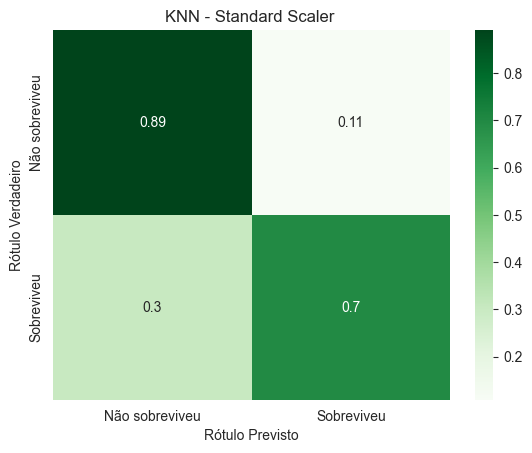

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



,Train Accuracy,Test Accuracy,Test f1
KNN - Modelo Base,0.81,0.75,0.73
KNN - Standard Scaler,0.87,0.82,0.80


In [16]:
#Treinar e avaliar o modelo com os dados padronizados
knn_sc=KNeighborsClassifier()
knn_sc.fit(Xtrain_scl, ytrain)
acc_train = knn_sc.score(Xtrain_scl, ytrain)
ypred_test=knn_sc.predict(Xtest_scl)
acc_test= accuracy_score(ytest, ypred_test)
model_evaluation(acc_train, ytest, ypred_test, "KNN - Standard Scaler ")

### Modelo com MinMaxScaler

In [18]:
Xtrain.describe()

,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0
count,712.000000,712.000000,712.00000,712.000000,712.000000,712.000000,712.000000
mean,2.317416,29.745184,31.86295,0.921348,0.653090,0.089888,0.728933
std,0.833767,13.089458,50.13531,1.664385,0.476321,0.286222,0.444823
min,1.000000,0.670000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,7.91770,0.000000,0.000000,0.000000,0.000000
50%,3.000000,29.745184,14.45625,0.000000,1.000000,0.000000,1.000000
75%,3.000000,35.000000,31.27500,1.000000,1.000000,0.000000,1.000000
max,3.000000,80.000000,512.32920,10.000000,1.000000,1.000000,1.000000


In [19]:
from sklearn.preprocessing import MinMaxScaler
MMscaler = MinMaxScaler(feature_range=(0,1))
Xtrain_MMscl=pd.DataFrame(MMscaler.fit_transform(Xtrain), columns = Xtrain.columns)
Xtest_MMscl = pd.DataFrame(MMscaler.transform(Xtest), columns=Xtest.columns)
Xtrain_MMscl.describe()

,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,0.658708,0.366509,0.062192,0.092135,0.653090,0.089888,0.728933
std,0.416884,0.165000,0.097858,0.166438,0.476321,0.286222,0.444823
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,0.268877,0.015454,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.366509,0.028217,0.000000,1.000000,0.000000,1.000000
75%,1.000000,0.432749,0.061045,0.100000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


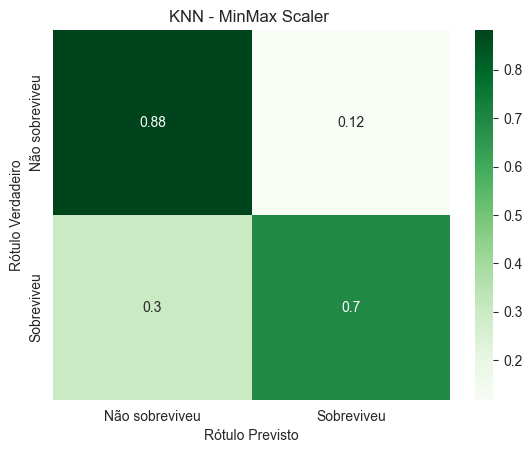

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



,Train Accuracy,Test Accuracy,Test f1
KNN - Modelo Base,0.81,0.75,0.73
KNN - Standard Scaler,0.87,0.82,0.80
KNN - MinMax Scaler,0.86,0.81,0.79


In [20]:
knn_MMScl=KNeighborsClassifier()
knn_MMScl.fit(Xtrain_MMscl, ytrain)

acc_train= knn_MMScl.score(Xtrain_MMscl, ytrain)
ypred_test=knn_MMScl.predict(Xtest_MMscl)
model_evaluation(acc_train, ytest, ypred_test, "KNN - MinMax Scaler ")

## Modelo com Robust Scaler

In [21]:
from sklearn.preprocessing import RobustScaler
RScaler = RobustScaler()
Xtrain_RScl=pd.DataFrame(RScaler.fit_transform(Xtrain), columns = Xtrain.columns)
Xtest_RScl = pd.DataFrame(RScaler.transform(Xtest), columns=Xtest.columns)
Xtrain_RScl.describe()

,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0
count,712.000000,7.120000e+02,7.120000e+02,712.000000,712.000000,712.000000,712.000000
mean,-0.682584,3.293246e-16,7.452360e-01,0.921348,-0.346910,0.089888,-0.271067
std,0.833767,1.006881e+00,2.146451e+00,1.664385,0.476321,0.286222,0.444823
min,-2.000000,-2.236553e+00,-6.189179e-01,0.000000,-1.000000,0.000000,-1.000000
25%,-1.000000,-5.957834e-01,-2.799360e-01,0.000000,-1.000000,0.000000,-1.000000
50%,0.000000,0.000000e+00,-3.801484e-17,0.000000,0.000000,0.000000,0.000000
75%,0.000000,4.042166e-01,7.200640e-01,1.000000,0.000000,0.000000,0.000000
max,0.000000,3.865755e+00,2.131552e+01,10.000000,0.000000,1.000000,0.000000


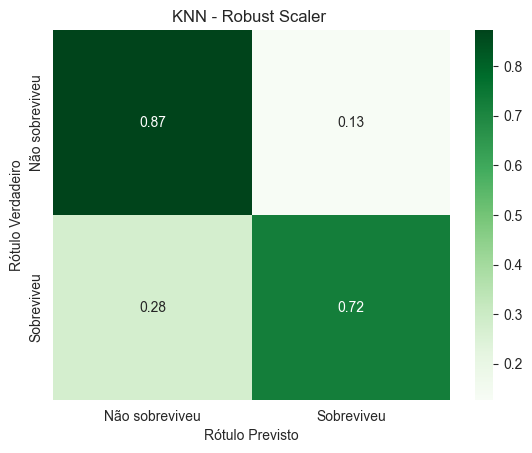

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



,Train Accuracy,Test Accuracy,Test f1
KNN - Modelo Base,0.81,0.75,0.73
KNN - Standard Scaler,0.87,0.82,0.80
KNN - MinMax Scaler,0.86,0.81,0.79
KNN - Robust Scaler,0.86,0.82,0.80


In [22]:
knn_RScl=KNeighborsClassifier()
knn_RScl.fit(Xtrain_RScl, ytrain)

acc_train= knn_RScl.score(Xtrain_RScl, ytrain)
ypred_test=knn_RScl.predict(Xtest_RScl)
model_evaluation(acc_train, ytest, ypred_test, "KNN - Robust Scaler ")

In [24]:
#odenar df performance por ordem  decrescente de valores de test-f1
performance.sort_values(by=["Test f1"], ascending=False, inplace=True)
display(performance)


,Train Accuracy,Test Accuracy,Test f1
KNN - Standard Scaler,0.87,0.82,0.80
KNN - Robust Scaler,0.86,0.82,0.80
KNN - MinMax Scaler,0.86,0.81,0.79
KNN - Modelo Base,0.81,0.75,0.73


Qualquer um dos modelos obtidos após padronização dos dados se comporta melhor do que o modelo original, o que seria expectável. 

Neste caso, qualquer um dos outros modelos após padronização seria perfeitamente aceitável.
Os três modelos obtidos após padronização não diferem significativamente entre si. Escolhemos para trabalho futuro o modelo obtido após a padronização com o `RobustScaler`, pois apresenta uma dos valores da  métrica f1-score mais elevado, assim como a menor diferença entre a exatidão de treino e de teste. Para além disso, é o modelo que possui a métrica f1 para a classe minoritária (1, ou "Sobreviveu") ligeiramente superior às restantes.  


# Validação cruzada


Tendo um modelo de base, é aconselhável optimizar os seus parâmetros. No caso de KNN, o parâmetro relevante é o número de vizinhos mais próximos que é utilizado para definir as regiões de decisão.

Existem várias formas de optimizar os hiperparâmetros de um modelo. A **validação cruzada**, sendo especialmente útil para avaliar a robustez de um modelo, pode também ser usada para encontrar os hiperparâmetros óptimos, sobretudo no caso em que são em pequeno número. 




![CrossVal](https://drive.google.com/uc?export=view&id=1yNicN9awlfb8JVSGxEqVzTDqzhwUS4yc)

Tal como nas abordagens que vimos até aqui, os dados começam por ser separados em conjunto de treino e conjunto de teste. 

A validação cruzada utiliza os dados de treino, treinando o modelo com uma parte desses dados e utilizando uma outra parte para fazer o teste do modelo (validação). Depois, repete o processo usando uma distribuição diferente dos dados para treinar e para testar. O processo é repetido um N determinado número de vezes, ao fim dos quais o modelo terá sido treinado e testado N vezes, sempre com subconjuntos diferentes de treino e de teste (validação). 

As métricas apresentadas são o valor médio das médias dos N modelos treinados, oferencenco, por isso, um valor mais robusto e fiável por comparação às métricas obtidas apenas para um modelo treinado.

Reforça-se que a  validazação cruzada não produz um modelo, mas sim um conjunto interno de modelos e respetivas métricas, apenas com o objetivo de avaliar quão bem um dado algoritmo é capaz de generalizar. 

Por fim, o modelo será testado no conjunto de dados deixado de lado inicialmente - o conjunto de teste.

Em `scikit learn` esse processo é feito recorrendo a funções de `model_selection`. 
No exemplo seguinte, utiliza-se a função `cross_val_score` que devolve a média da exatidão obtida nos modelos treinados com diferentes subconjuntos treino/teste. O parâmetro `cv` representa em quantas partes o conjunto de dados vai ser repartido e, também, quantas vezes o modelo é treinado e testado. Por omissão, `cv=5`.


A documentação sobre esta função pode ser consultada aqui: https://scikit-learn.org/stable/modules/cross_validation.html

## Validação cruzada

Comecemos por usar a validação cruzada para melhor avaliar o modelo criado com os dados padronizados com o RobustScaler

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(knn_RScl, Xtrain_RScl, ytrain, cv=5, scoring="accuracy")
print("Exatidão com Validação Cruzada : {}".format(scores))
print("Valor médio: %.2f" %scores.mean())
print("Desvio Padrão : %.2f" %scores.std())

Exatidão com Validação Cruzada : [0.75524476 0.82517483 0.74647887 0.77464789 0.79577465]
Valor médio: 0.78
Desvio Padrão : 0.03


De reparar que o valor de exatidão obtido anteriomente para os dados padronizados com o RobustScaler (0.86) é superior ao valor mais elevado obtido com a validação cruzada. Ou seja, a qualidade do modelo estava sobrevalorizada. A validação cruzada permite, portanto, estimar a qualidade do modelo (com os dados de treino) de uma forma mais robusta.

Repare-se que dos 5 valores obtidos com a validação cruzada, apenas um se assemelha ao obtido anteriormente, sendo a média mais baixa do que esse valor. Há uma razoável variabilidade nos valores obtidos, o que pode significar que o modelo depende bastante do subconjunto usado para treino, ou poderá ser apenas uma consequência do pequeno tamanho do conjunto de dados. 

## Validação cruzada para optimizar o parâmetro do modelo 

No exemplo seguinte usa-se a validação cruzada para encontrar o valor de k que optimiza a exatidão do modelo.

In [30]:
from sklearn.model_selection import cross_val_score
#lista de valores de k a considerar para KNN
lista_k= list(range(2,30,1))
#lista vazia para guardar valores de exatidão
#obtidos para cada modelo da validação cruzada.
train_acc=[]


#utilizar validação cruzada com cv=5
for k in lista_k:
    knn=KNeighborsClassifier(n_neighbors=k)
    scores=cross_val_score(knn, Xtrain_RScl, ytrain, cv=5, scoring="accuracy")
    train_acc.append(scores.mean())
 

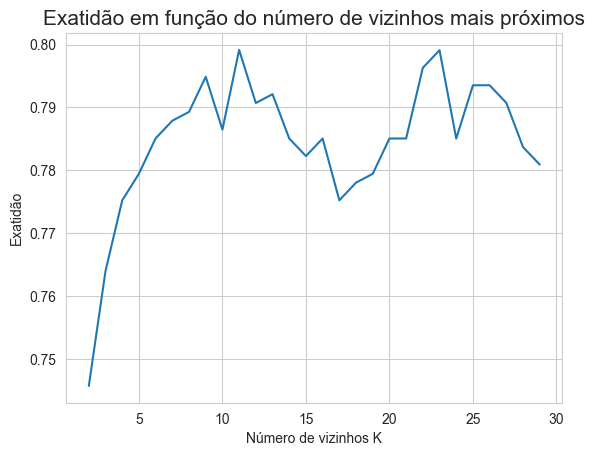

In [31]:
plt.figure()
plt.title('Exatidão em função do número de vizinhos mais próximos', fontsize=15)
plt.xlabel('Número de vizinhos K', fontsize=10)
plt.ylabel('Exatidão', fontsize=10)
sns.set_style("whitegrid")
plt.plot(lista_k, train_acc)

plt.show()

In [32]:
print("Exatidão máxima: %.2f" % max(train_acc))
k_optimo = lista_k[train_acc.index(max(train_acc))]
print("k optimo:  %d" % k_optimo )

Exatidão máxima: 0.80
k optimo:  11


Para finalizar, treinamos o modelo com o k encontrado e verificamos a sua performance.

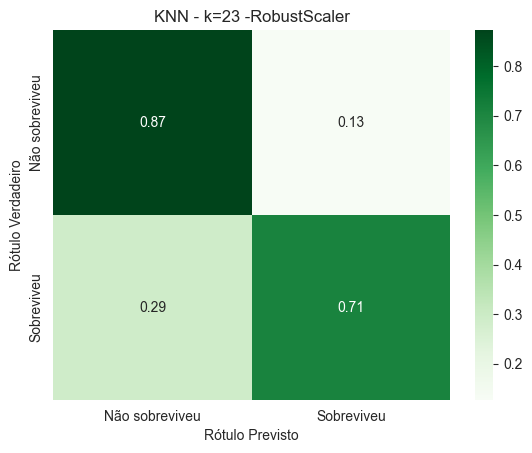

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



,Train Accuracy,Test Accuracy,Test f1
KNN - Standard Scaler,0.87,0.82,0.80
KNN - Robust Scaler,0.86,0.82,0.80
KNN - MinMax Scaler,0.86,0.81,0.79
KNN - Modelo Base,0.81,0.75,0.73
KNN - k=23 -RobustScaler,0.83,0.81,0.80


In [35]:
knn_final=KNeighborsClassifier(n_neighbors=k_optimo)
knn_final.fit(Xtrain_RScl, ytrain)
ypred_test=knn_final.predict(Xtest_RScl)
acc_train= knn_final.score(Xtrain_RScl, ytrain)

model_evaluation(acc_train, ytest, ypred_test, "KNN - k=23 -RobustScaler")


Obtém-se um modelo com métrica f1 semelhante aos dois melhores modelos treinados antes, mas com menor diferença entre as exatidões de treino/teste